# A Multiclass Classification model

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.datasets import make_blobs

In [ ]:
# 1. setting the Hyperparameters

num_classes = 4
num_features = 2

# 2 . Create a milticlass Data

X , y = make_blobs(n_samples = 1000,
                   n_features= num_features,
                   centers= num_classes,
                   cluster_std=  1.6,
                   random_state = 42)
len(X) , len(y)

(1000, 1000)

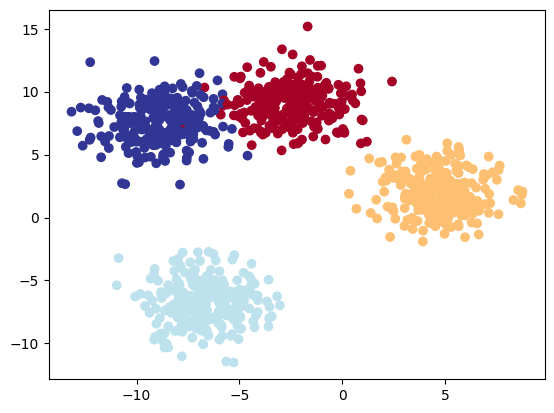

In [ ]:
plt.scatter(
    x= X[:,0] , y =X[:,1] , c=y , cmap = 'RdYlBu'
)

In [ ]:
# 2. As a Data is generated IN Numpy
print(type(X))

# 3. Changing the Datatypes
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.LongTensor)
print(type(X))
print(type(y))

<class 'numpy.ndarray'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [ ]:
# 1. plotting the Data for Training
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X,
                                                       y,
                                                       test_size = 0.2,
                                                       random_state= 42)
len(X_train) , len(X_test) , len(y_train) , len(y_test)

(800, 200, 800, 200)

# Building the PyTorch Multiclass Classificaation Model


In [ ]:
# 1. Setting Agnostic code
device = "Cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
# building the MOdel

class BlobModel(nn.Module):
  def __init__(self, input_features , output_features , hidden_units = 8):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_features)
    )

  def forward (self , x):
    return self.linear_layer_stack(x)


#create a instance for the BlodModel
model = BlobModel(input_features=2,
                  output_features=4,
                  hidden_units = 8).to(device)

model

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [ ]:
# 1. creating the Accuracy function
def accuracy_fn(y_true , y_pred):
  """
  torch.eq is used here to find out the similar values in the test and the pred which return the Values in the binary and then sum() use to sum the value of true hoe much are the true values and .item() used to get the value of the tensor
  """
  correct = torch.eq(y_true , y_pred).sum().item()
  return (correct / len(y_pred)) * 100

In [ ]:
# 1. Traingg the Model
loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(),
                            lr=0.1)

# Getting prediction probabilites for a multi class PyTorch model

in order to evaluate and trian and test our model we need to convert our model outputs to prediction probabil;iite  and then prediction labels
logits -> pred prob -> pred labels

### to go from the raw otput to prediction proba to predictions labels

y_logits (raw output of the models) --> y_pred_proba (use `torch.Softmax()` here)--> ypreds (use the `argmax()` here)

In [ ]:
model.eval()
with torch.inference_mode():
  y_logits = model(X_test.to(device))
y_logits[:10]

tensor([[-0.7759, -0.7571, -1.5995, -1.1496],
        [-0.0958, -0.9399, -0.5933, -0.1365],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4002, -0.5146, -0.9082, -0.6816],
        [-0.3203, -1.3908, -1.2220, -0.3923],
        [-0.1520, -1.0667, -0.7158, -0.1659],
        [ 0.1391, -0.2996,  0.1343, -0.0234],
        [-0.2155, -1.1796, -0.9304, -0.2747],
        [ 0.2425, -0.2510,  0.1602,  0.0064],
        [-0.2345, -1.2150, -0.9906, -0.3033]])

In [ ]:
# convert our model models tp prediction proba
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-0.7759, -0.7571, -1.5995, -1.1496],
        [-0.0958, -0.9399, -0.5933, -0.1365],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4002, -0.5146, -0.9082, -0.6816],
        [-0.3203, -1.3908, -1.2220, -0.3923]])
tensor([[0.3179, 0.3239, 0.1395, 0.2187],
        [0.3335, 0.1434, 0.2028, 0.3202],
        [0.3011, 0.1843, 0.2823, 0.2323],
        [0.3079, 0.2746, 0.1852, 0.2323],
        [0.3733, 0.1280, 0.1515, 0.3473]])


In [ ]:
#1. convert model predictions probabilites to the predictions labels
ypreds = torch.argmax(y_pred_probs , dim=1)
ypreds

tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 3, 0, 0, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 1, 0, 1, 0, 0, 0,
        0, 0, 0, 3, 3, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 1, 0, 1])

##### **Creating a training and testing loop**



In [ ]:
# 1. setting the multiclass  model to data

torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 100

for epoch in range(epochs):
  # trainng the model class

  model.train()

  y_logits = model(X_train)
  y_preds = torch.softmax(y_logits , dim=1).argmax(dim=1)

  loss = loss_fn(y_logits , y_train)
  acc  = accuracy_fn(y_true=y_train,
                     y_pred=y_preds)

  optimizer.zero_grad()

  loss.backward()
  optimizer.step()

  # 2. testing teh modl
  model.eval()
  with torch.inference_mode():
    test_logits = model(X_test)
    test_preds = torch.softmax(test_logits , dim=1).argmax(dim=1)
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_preds)

  if epoch % 10 == 0:
    print(f"Epoch : {epoch} | loss : {loss:.5f} | acc : {acc:.2f}% | test_loss : {test_loss:.5f} | test_acc : {test_acc:.2f}%")


Epoch : 0 | loss : 1.16036 | acc : 41.12% | test_loss : 1.07755 | test_acc : 49.50%
Epoch : 10 | loss : 0.65104 | acc : 96.12% | test_loss : 0.66659 | test_acc : 97.00%
Epoch : 20 | loss : 0.43472 | acc : 98.00% | test_loss : 0.44030 | test_acc : 99.00%
Epoch : 30 | loss : 0.26578 | acc : 98.62% | test_loss : 0.25811 | test_acc : 99.50%
Epoch : 40 | loss : 0.12472 | acc : 98.88% | test_loss : 0.11382 | test_acc : 99.50%
Epoch : 50 | loss : 0.07655 | acc : 98.88% | test_loss : 0.06770 | test_acc : 99.50%
Epoch : 60 | loss : 0.06053 | acc : 98.88% | test_loss : 0.05152 | test_acc : 99.50%
Epoch : 70 | loss : 0.05279 | acc : 98.88% | test_loss : 0.04342 | test_acc : 99.50%
Epoch : 80 | loss : 0.04830 | acc : 98.88% | test_loss : 0.03854 | test_acc : 99.50%
Epoch : 90 | loss : 0.04535 | acc : 98.88% | test_loss : 0.03519 | test_acc : 99.50%


In [ ]:
y_logits.dtype

torch.float32

In [ ]:
import requests
from pathlib import Path

# 1 downlaod the helper function if it is not downloaded

if Path("helper_functions.py").is_file():
  print("The helper_functions.py exists")
else:
  print("downloading the file")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)
  from helper_functions import plot_predictions , plot_decision_boundary
  print("done")

The helper_functions.py exists


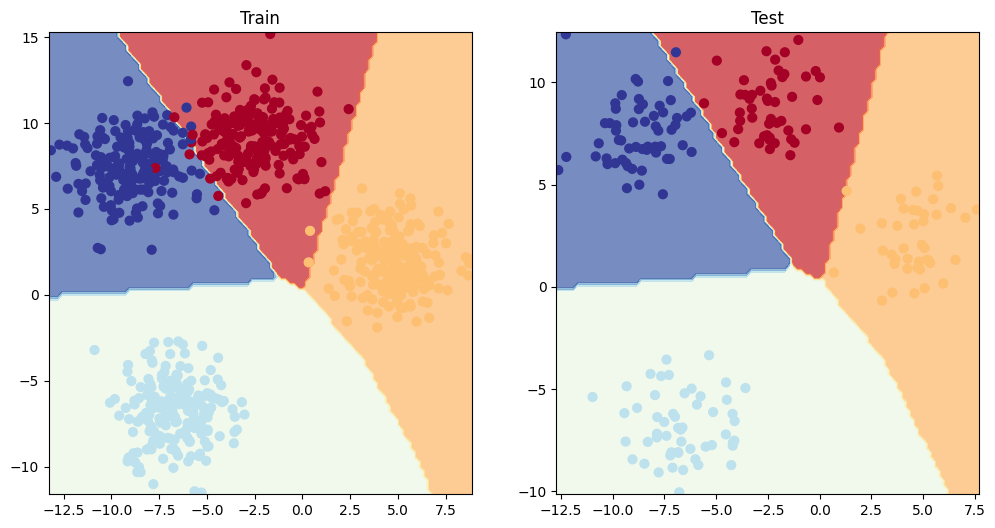

In [ ]:
# 1. plot the decison boundries of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model=model, X=X_train, y=y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model , X_test, y_test)

In [ ]:
# 1. making and Evaluatig the predictions with Pytorch multiclass Model
# 2. make predictions
model.eval()
with torch.inference_mode():
  y_logits = model(X_test)

# 3.view the first 10
print(y_logits[:10])

# 4. prediction proba
y_proba = torch.softmax(y_logits , dim =1)

print(y_proba[:10])

#converting to the labels
y_pred = torch.argmax(y_proba , dim=1)
print(y_pred[:10])
print(y_test[:10])

tensor([[-0.4981,  6.0645, -7.8511, -8.5669],
        [-2.0286, -6.3657, -3.8128,  3.0335],
        [-3.4235, -3.8962,  3.1524, -2.6081],
        [-1.1447,  4.2264, -3.8199, -4.8088],
        [ 3.8003, -1.3176, -9.3710, -6.9320],
        [-2.7275, -7.6544, -4.4209,  3.7797],
        [-3.0199, -3.2961,  2.7805, -2.1153],
        [ 3.3387, -4.1913, -6.9651, -3.3923],
        [-4.4275, -5.0621,  3.8422, -3.4229],
        [ 3.5478, -3.1231, -7.6326, -4.5670]])
tensor([[1.4101e-03, 9.9859e-01, 9.0341e-07, 4.4161e-07],
        [6.2858e-03, 8.2182e-05, 1.0555e-03, 9.9258e-01],
        [1.3861e-03, 8.6396e-04, 9.9462e-01, 3.1325e-03],
        [4.6253e-03, 9.9494e-01, 3.1866e-04, 1.1853e-04],
        [9.9402e-01, 5.9529e-03, 1.8930e-06, 2.1698e-05],
        [1.4900e-03, 1.0801e-05, 2.7399e-04, 9.9823e-01],
        [2.9881e-03, 2.2670e-03, 9.8736e-01, 7.3834e-03],
        [9.9824e-01, 5.3582e-04, 3.3447e-05, 1.1912e-03],
        [2.5589e-04, 1.3566e-04, 9.9891e-01, 6.9876e-04],
        [9.9842e-

#### A few more classificatios metrics

* Accuracy  `torchmetrics.Accuracy()` or `sklearn.metrics.accuracy_score()`

* Precision   `torchmetrics.Precision()` or `sklearn.metrics.precision_score()`

* Recall   `torchmetrics.Recall()` or `sklearn.metrics.recall_score()`

* F1-Score   `torchmetrics.F1Score()` or `sklearn.metrics.f1_score()`

* Confusion - matrix  `torchmetrics.ConfusionMatrix()`

* Clasification Report


In [ ]:
# 1. Checking the Other classification metrics
%pip install torchmetrics
import torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 17.3 MB/s eta 0:00:00


In [ ]:
from torchmetrics import Accuracy

torchAcc = Accuracy(task="multiclass",
                    num_classes = classes)

torchAcc(y_pred, y_test)

tensor(0.9950)

In [ ]:
classes = len(torch.unique(y_pred))

In [ ]:
classes

4